In [1]:
! pip install arch
! pip install statsmodels.api
! pip install yfinance
! pip install pyts
!pip install keras_tuner
# For fractional differencing
#!pip install fracdiff
#from fracdiff import Fracdiff

ERROR: Could not find a version that satisfies the requirement statsmodels.api (from versions: none)
ERROR: No matching distribution found for statsmodels.api


In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_palette("Set2")
import statsmodels.api as sm
from arch.unitroot import ADF, KPSS
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

# For MLP
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import matplotlib.pyplot as plt
from pyts.image import GramianAngularField
import tensorflow as tf
import keras_tuner as kt
from keras_tuner import HyperModel
from keras import backend as K

In [3]:
data = yf.download("^VIX", start="2015-01-01", end = '2025-11-01')['Close']
data.head()


/tmp/ipython-input-2871826538.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^VIX", start="2015-01-01", end = '2025-11-01')['Close']
[*********************100%***********************]  1 of 1 completed


Ticker,^VIX
Date,
2015-01-02,17.790001
2015-01-05,19.920000
2015-01-06,21.120001
2015-01-07,19.309999
2015-01-08,17.010000


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2725 entries, 2015-01-02 to 2025-10-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ^VIX    2725 non-null   float64
dtypes: float64(1)
memory usage: 42.6 KB


In [5]:
data[data['^VIX'] == data['^VIX'].max()]

Ticker,^VIX
Date,
2020-03-16,82.690002


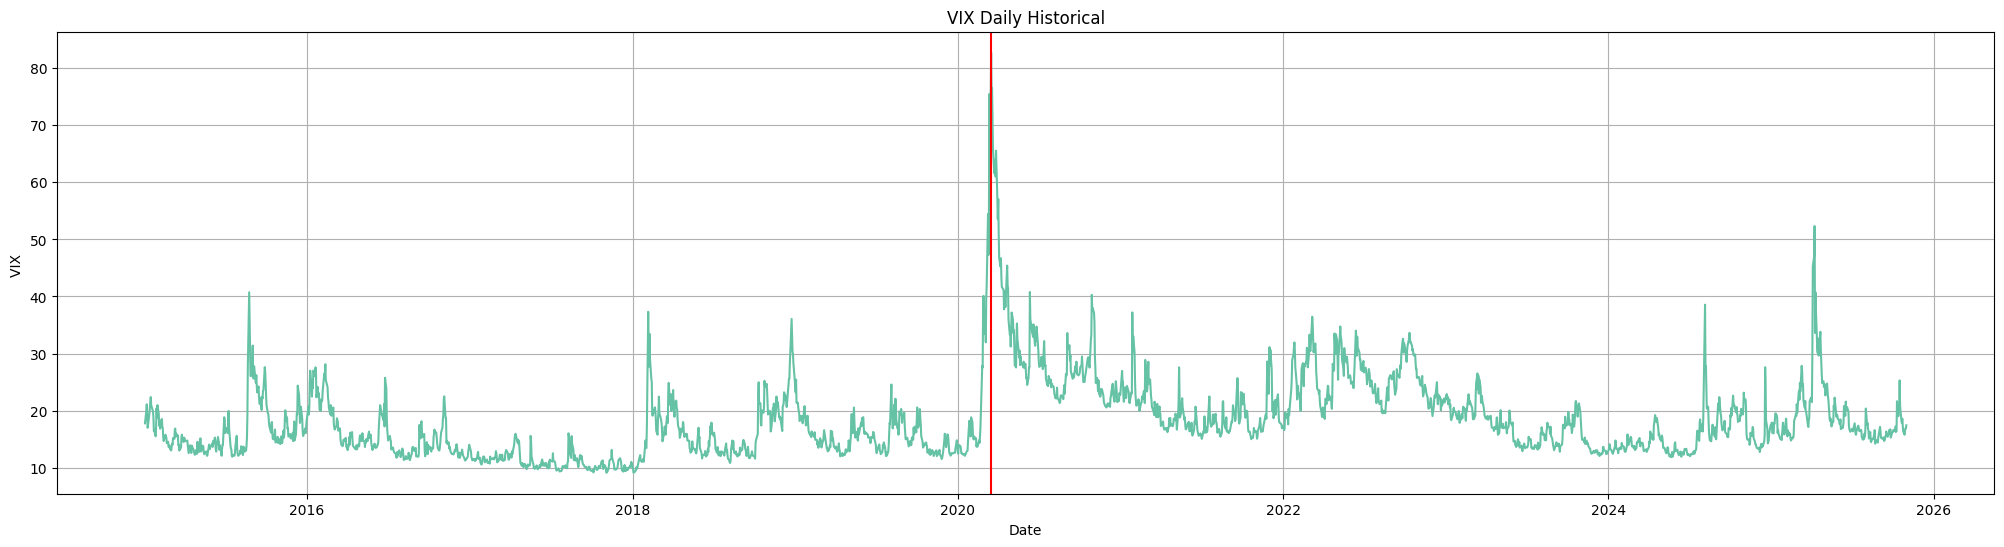

In [6]:
plt.figure(figsize=(25, 6))
plt.plot(data.index, data['^VIX'])
plt.title("VIX Daily Historical")
plt.xlabel("Date")
plt.ylabel("VIX ")
plt.axvline(pd.to_datetime("2020-03-16"), color = 'red')
plt.grid(True)
plt.show()

A peak is seen on March 2020 because of COVID pandemic.(https://en.wikipedia.org/wiki/2020_stock_market_crash)

In [7]:
data.describe()

Ticker,^VIX
count,2725.000000
mean,18.342818
std,7.172723
min,9.140000
25%,13.530000
50%,16.500000
75%,21.290001
max,82.690002


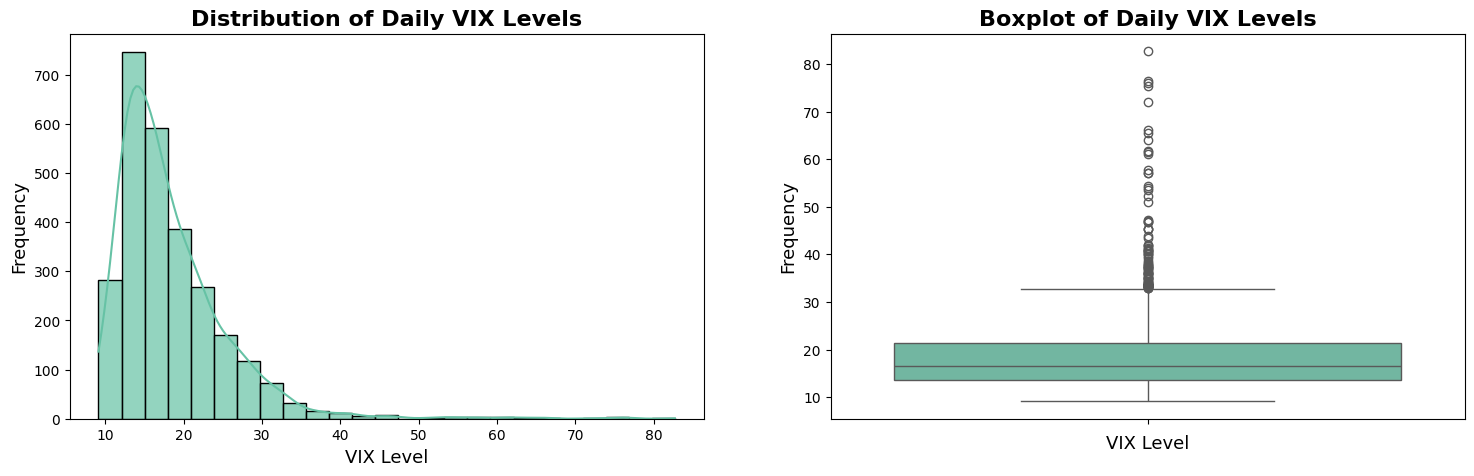

In [8]:
fix, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(data['^VIX'],bins=25,kde=True,edgecolor='black',alpha=0.7, ax = axes[0])
axes[0].set_title("Distribution of Daily VIX Levels", fontsize=16, weight='bold')
axes[0].set_xlabel("VIX Level", fontsize=13)
axes[0].set_ylabel("Frequency", fontsize=13)

sns.boxplot(data['^VIX'], ax = axes[1])
axes[1].set_title("Boxplot of Daily VIX Levels", fontsize=16, weight='bold')
axes[1].set_xlabel("VIX Level", fontsize=13)
axes[1].set_ylabel("Frequency", fontsize=13)

plt.show()

The distribution shows right skeness, with mean 18.34% and median 16.50. VIX between 15 and 25 considered moderate and between 25 to 30 as highly volatile market. As we see the boxplot, VIX higher than 35 are considered as outliers.

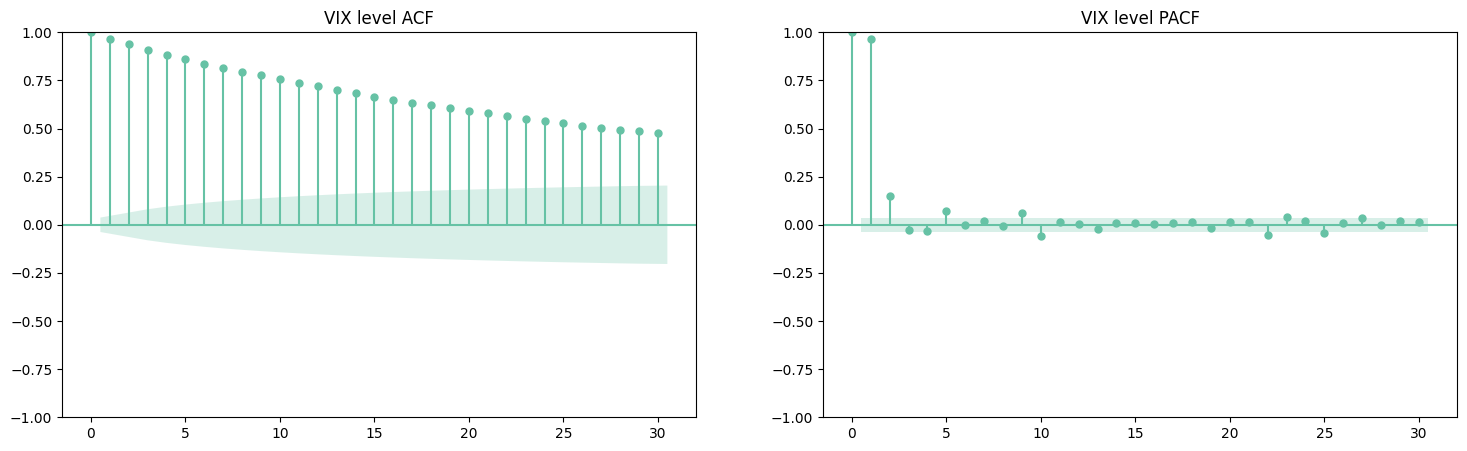

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(18, 5))
sm.graphics.tsa.plot_acf(data['^VIX'], title="VIX level ACF", lags=30, ax=ax[0])
sm.graphics.tsa.plot_pacf(data['^VIX'], title="VIX level PACF", lags=30, ax=ax[1])
plt.show()

Weak stationary : when mean and autocovariance are independet of time. ACF shows a high declining trend, so VIX timeseries is not stationary also ACF shows there is a trend in the timeseire.
  

In [10]:
data_1_a = data['^VIX']

#### **Step 1-b**

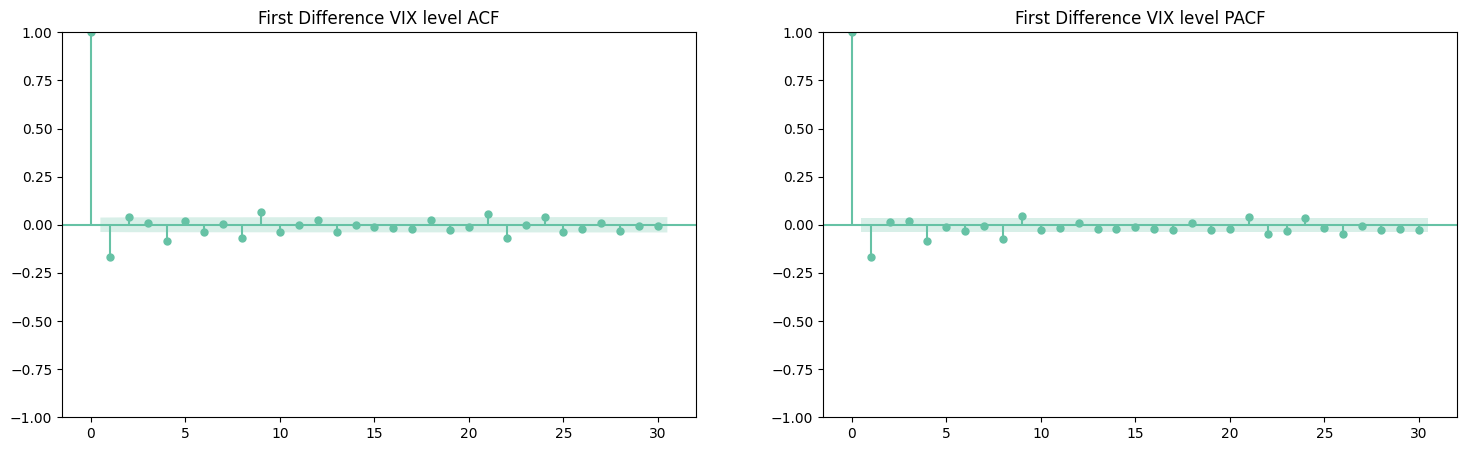

In [11]:
data_1_b = pd.DataFrame()
data_1_b['diff_Close'] = data['^VIX'].diff()

data_1_b = data_1_b.dropna()
fig, ax = plt.subplots(1, 2, figsize=(18, 5))
sm.graphics.tsa.plot_acf(data_1_b['diff_Close'], title="First Difference VIX level ACF", lags=30, ax=ax[0])
sm.graphics.tsa.plot_pacf(data_1_b['diff_Close'], title="First Difference VIX level PACF", lags=30, ax=ax[1])
plt.show()

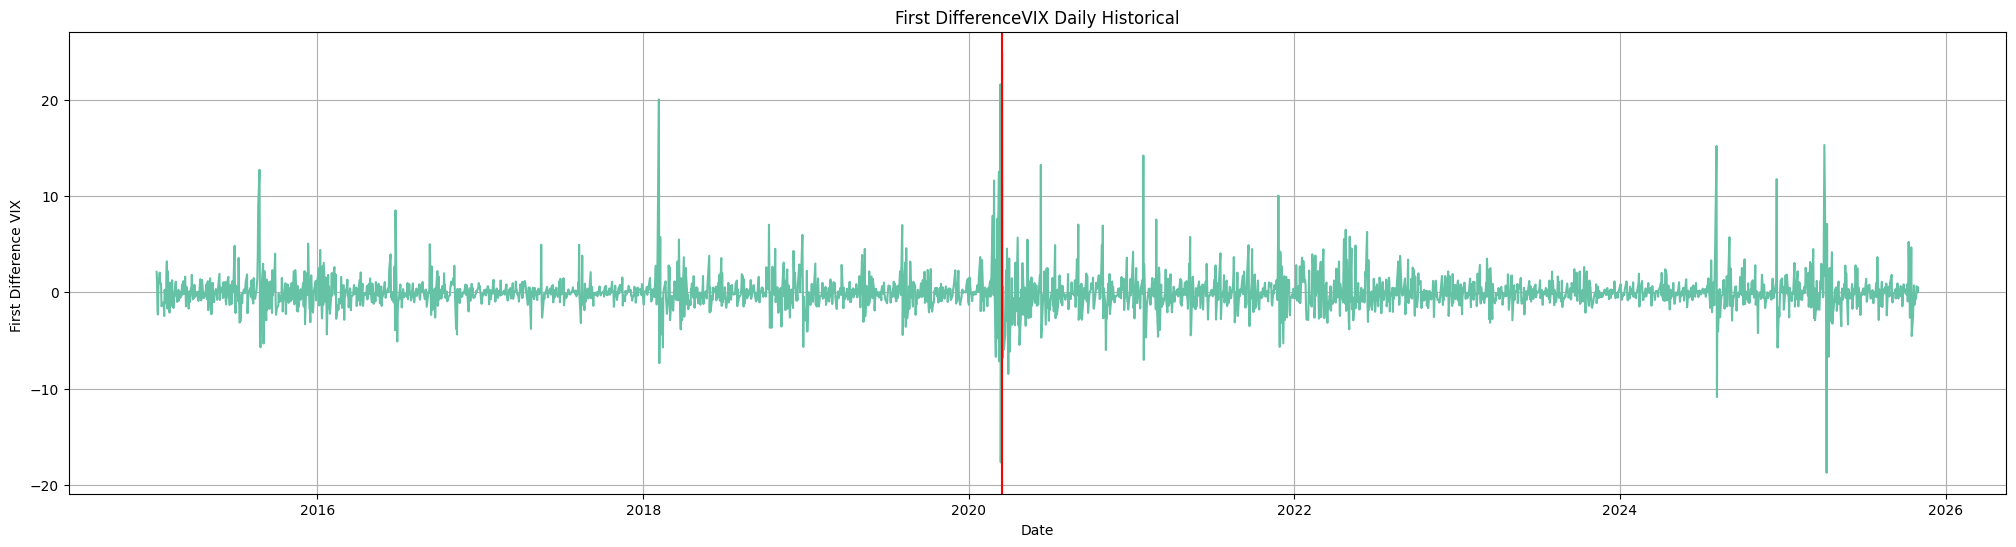

In [12]:
plt.figure(figsize=(25, 6))
plt.plot(data_1_b.index, data_1_b['diff_Close'])
plt.title("First DifferenceVIX Daily Historical")
plt.xlabel("Date")
plt.ylabel("First Difference VIX ")
plt.axvline(pd.to_datetime("2020-03-16"), color = 'red')
plt.grid(True)
plt.show()

In [13]:
# ADF test without drift and trend
adf_n = ADF(data_1_b['diff_Close'], trend="n", method="bic")
print("Augmented Dickey-Fuller Unit Root Test\n", adf_n.regression.summary())
print("\nTest statistics and critical values: \n", adf_n)
# ADF test with drift and without trend
adf_c = ADF(data_1_b['diff_Close'], trend="c", method="bic")
print("Augmented Dickey-Fuller Unit Root Test\n", adf_c.regression.summary())
print("\nTest statistics and critical values: \n", adf_c)
# ADF test with drift and trend
adf_none = ADF(data_1_b['diff_Close'], trend="ct", method="bic")
print("Augmented Dickey-Fuller Unit Root Test\n", adf_none.regression.summary())
print("\nTest statistics and critical values: \n", adf_none)


Augmented Dickey-Fuller Unit Root Test
                                  OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.583
Model:                            OLS   Adj. R-squared (uncentered):              0.583
Method:                 Least Squares   F-statistic:                              3803.
Date:                Thu, 27 Nov 2025   Prob (F-statistic):                        0.00
Time:                        22:17:42   Log-Likelihood:                         -5658.4
No. Observations:                2723   AIC:                                  1.132e+04
Df Residuals:                    2722   BIC:                                  1.132e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-

In [14]:
print(KPSS(data_1_b['diff_Close'], trend="ct", lags=-1))

    KPSS Stationarity Test Results   
Test Statistic                  0.010
P-value                         0.997
Lags                               28
-------------------------------------

Trend: Constant and Linear Time Trend
Critical Values: 0.22 (1%), 0.15 (5%), 0.12 (10%)
Null Hypothesis: The process is weakly stationary.
Alternative Hypothesis: The process contains a unit root.


$H_0$ for KPSS states that the time series is stationary while $H_0$ for ADF states that there is a unit root, so the time series is not stationary.
In ADF, Test Statistic << critical value(5%) and in KPSS p-value > 0.05 so the
first difference of time series is stationary.


In [15]:
data_1_b = data_1_b['diff_Close']

### **Step 1-c**



optimal fractinal differencing 0.12


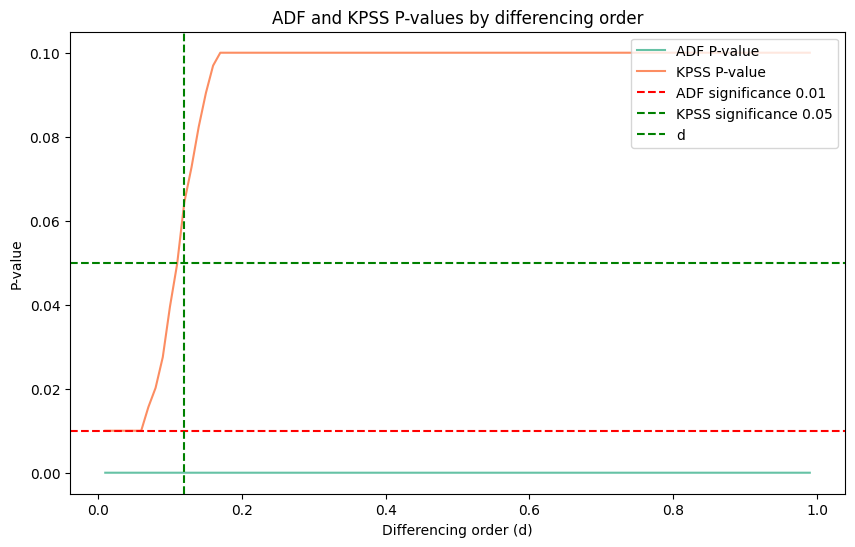

In [16]:
import warnings
warnings.filterwarnings('ignore')

def getWeights(d,lags):
    # return the weights from the series expansion of the differencing operator
    # for real orders d and up to lags coefficients
    w=[1]
    for k in range(1,lags):
        w.append(-w[-1]*((d-k+1))/k)
    w=np.array(w).reshape(-1,1)
    return w

def cutoff_find(order,cutoff,start_lags): #order is our dearest d, cutoff is 1e-4 for us, and start lags is an initial amount of lags in which the loop will start, this can be set to high values in order to speed up the algo
    val=np.inf
    lags=start_lags
    while abs(val)>cutoff:
        w=getWeights(order, lags)
        val=w[len(w)-1]
        lags+=1
    return lags


def ts_differencing_tau(series, order, tau):
  # return the time series resulting from (fractional) differencing
  lag_cutoff=(cutoff_find(order,tau,1)) #finding lag cutoff with tau
  weights=getWeights(order, lag_cutoff)
  res=0
  for k in range(lag_cutoff):
    res += weights[k]*series.shift(k).fillna(0)
  return res[lag_cutoff:]

possible_d=np.divide(range(1,100),100)
tau=1e-4
adf_stat_holder=[None]*len(possible_d)
kpss_stat_holder=[None]*len(possible_d)


for i in range(len(possible_d)):
  diffed = ts_differencing_tau(data['^VIX'], possible_d[i], tau)
  adf_stat_holder[i]=adfuller(diffed)[1]
  kpss_stat_holder[i]=kpss(diffed)[1]

optimal_d = []
for i in range(len(possible_d)):
  if adf_stat_holder[i] <= 0.01 and kpss_stat_holder[i] >= 0.05:
    optimal_d.append(possible_d[i])

print('optimal fractinal differencing',min(optimal_d))
fig = plt.figure(figsize=(10, 6))
plt.plot(possible_d, adf_stat_holder, label='ADF P-value')
plt.plot(possible_d, kpss_stat_holder, label='KPSS P-value')
plt.axhline(y=0.01, color='r', linestyle='--', label='ADF significance 0.01')
plt.axhline(y=0.05, color='g', linestyle='--', label='KPSS significance 0.05')
plt.axvline(x=min(optimal_d) , color='g', linestyle='--', label='d')

plt.legend(loc = 'upper right')
plt.title('ADF and KPSS P-values by differencing order')
plt.xlabel('Differencing order (d)')
plt.ylabel('P-value')
plt.show()

In [17]:
data_1_c = ts_differencing_tau(data['^VIX'], 0.12, tau)

### **Step 2**

In [18]:
# -------------------------------
# Step 2: Build MLP models
# -------------------------------
def make_lagged_df(series, lags):
    """Make a DataFrame of lagged values for a time series."""
    df = pd.DataFrame({f"lag_{i}": series.shift(i) for i in range(1, lags+1)})
    df["y"] = series.values
    df = df.dropna()
    return df

lags = 5


# Prepare datasets
df_levels = make_lagged_df(data_1_a, lags)
df_logdiff = make_lagged_df(data_1_b, lags)
df_fd = make_lagged_df(data_1_c, lags)

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Performance on test set:
Levels model — MSE: 4.262549, MAE: 1.063087
Log-diff model — MSE: 1.716189, MAE: 0.697469
Frac-diff model — MSE: 65.054939, MAE: 7.581117


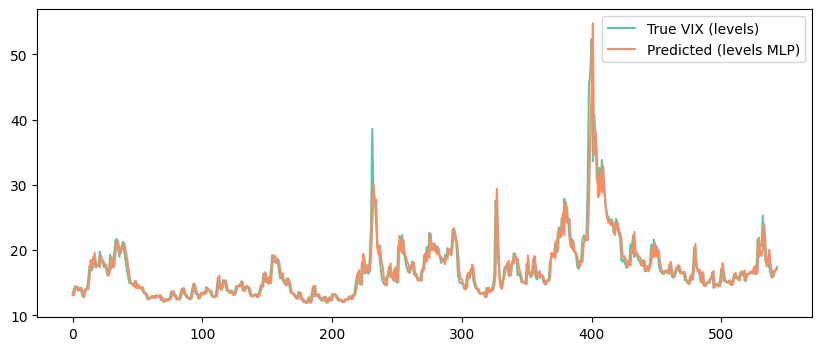

In [19]:
# Train / test split
def split_scale(df):
    X = df.drop("y", axis=1).values
    y = df["y"].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()
    return X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, scaler_X, scaler_y, y_test

X_l, Xl_te, y_l_tr, y_l_te, scX_l, scY_l, y_l_test = split_scale(df_levels)
X_ld, Xld_te, y_ld_tr, y_ld_te, scX_ld, scY_ld, y_ld_test = split_scale(df_logdiff)
X_fd, Xfd_te, y_fd_tr, y_fd_te, scX_fd, scY_fd, y_fd_test = split_scale(df_fd)

# Build a simple MLP model function
def build_train_mlp(X_train, y_train, X_test, y_test, scaler_y, epochs=100, hidden_units=[64, 32]):
    model = Sequential()
    model.add(Dense(hidden_units[0], activation='relu', input_shape=(X_train.shape[1],)))
    for units in hidden_units[1:]:
        model.add(Dense(units, activation='relu'))
    model.add(Dense(1))  # output layer

    model.compile(optimizer='adam', loss='mse')
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                        epochs=epochs, verbose=0)
    # Predictions
    y_pred_train = model.predict(X_train).flatten()
    y_pred_test = model.predict(X_test).flatten()
    # Inverse scale
    y_pred_train_rescaled = scaler_y.inverse_transform(y_pred_train.reshape(-1,1)).flatten()
    y_pred_test_rescaled = scaler_y.inverse_transform(y_pred_test.reshape(-1,1)).flatten()
    return model, history, y_pred_train_rescaled, y_pred_test_rescaled

# Train the three models
mlp_levels, hist_levels, ypred_l_tr, ypred_l_te = build_train_mlp(X_l, y_l_tr, Xl_te, y_l_te, scY_l)
mlp_logdiff, hist_logdiff, ypred_ld_tr, ypred_ld_te = build_train_mlp(X_ld, y_ld_tr, Xld_te, y_ld_te, scY_ld)
mlp_fd, hist_fd, ypred_fd_tr, ypred_fd_te = build_train_mlp(X_fd, y_fd_tr, Xfd_te, y_fd_te, scY_fd)

# Evaluate performance
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate(y_true, y_pred, label=""):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{label} — MSE: {mse:.6f}, MAE: {mae:.6f}")

print("Performance on test set:")
evaluate(y_l_test, ypred_l_te, "Levels model")
evaluate(y_ld_te, ypred_ld_te, "Log-diff model")
evaluate(y_fd_te, ypred_fd_te, "Frac-diff model")

# Optionally, plot predictions vs true
plt.figure(figsize=(10,4))
plt.plot(y_l_test, label="True VIX (levels)")
plt.plot(ypred_l_te, label="Predicted (levels MLP)")
plt.legend()
plt.show()



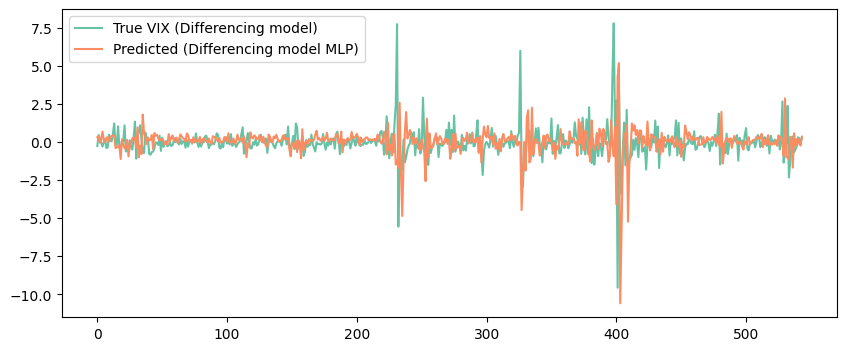

In [20]:
# Optionally, plot predictions vs true
plt.figure(figsize=(10,4))
plt.plot(y_ld_te, label="True VIX (Differencing model)")
plt.plot(ypred_ld_te, label="Predicted (Differencing model MLP)")
plt.legend()
plt.show()

In [30]:
def split_scale(df):
    X = df.drop("y", axis=1).values
    y = df["y"].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()
    return X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, scaler_X, scaler_y, y_test, y_train

X_l, Xl_te, y_l_tr, y_l_te, scX_l, scY_l, y_l_test, y_l_train = split_scale(df_levels)
X_ld, Xld_te, y_ld_tr, y_ld_te, scX_ld, scY_ld, y_ld_test, y_ld_train = split_scale(df_logdiff)
X_fd, Xfd_te, y_fd_tr, y_fd_te, scX_fd, scY_fd, y_fd_test, y_fd_train = split_scale(df_fd)

evaluate(y_l_train, ypred_l_tr, "Levels model")
evaluate(y_ld_train, ypred_ld_tr, "Log-diff model")
evaluate(y_fd_train, ypred_fd_tr, "Frac-diff model")

Levels model — MSE: 2.743352, MAE: 1.043033
Log-diff model — MSE: 2.061609, MAE: 0.963735
Frac-diff model — MSE: 2.968573, MAE: 1.054819


### **Step 3**

In [21]:
def X_train_array(series, window_size):
  x_train = []
  for i in range(window_size, series.shape[0]):
      x_train.append(series[i - window_size : i])
  return np.array(x_train) # the output will be (X.shape[0]-windowSize, windoSizwe, features)

def gaf_func(X_train, n_features, window_size):
  gaf = GramianAngularField(image_size=window_size,sample_range=(-1, 1), method='summation')
  gaf_channels = []
  for f in range(n_features):
    feature_series = X_train[:, :, f]
    gaf_img = gaf.fit_transform(feature_series)
    gaf_channels.append(gaf_img)
  X_gaf = np.stack(gaf_channels, axis=-1) # here we have X.shape[0]-windowSize number of images with size windoSizwe*windoSizwe (shows time) for n features
  return X_gaf

def plot_lags(n_features, X_gaf):
    fig, ax = plt.subplots(n_features, 1, figsize=(12, 3*n_features))
    if n_features == 1:
        ax = [ax]
    for i in range(n_features):
        ax[i].imshow(X_gaf[0, :, :, i], cmap="rainbow")
        ax[i].set_title(f"Lag {i+1}")
        ax[i].axis('off')
    plt.tight_layout()
    plt.show()

scaler_y = StandardScaler()
def split_data(X_data, y_data, scaler_y):

    y_scaled = scaler_y.fit_transform(y_data.reshape(-1,1)).ravel()

    X_scaled = (X_data + 1)/2 # map data from [-1,1] to [0,1]
    X_scaled = X_scaled *255 # map to standard 8-bit image range

    n = y_scaled.shape[0]
    train_size = int(0.8 * n)
    y_train_actual = y_data[:train_size]
    y_test_actual = y_data[train_size:]

    X_train = X_scaled[:train_size]
    X_test  = X_scaled[train_size:]

    y_train = y_scaled[:train_size]
    y_test  = y_scaled[train_size:]

    return y_train_actual, y_test_actual, X_train, X_test, y_train, y_test

tf.keras.backend.clear_session()
tf.random.set_seed(1234)
val_split = 0.2

class CNN_model(kt.HyperModel):
    def build(self, hp):
        act_fun = "relu"
        n_dropout = hp.Choice("n_dropout", values=[0.2, 0.5])
        num_layers = hp.Int("num_layers", 2, 3)

        model = tf.keras.Sequential()
        model.add(tf.keras.layers.InputLayer(input_shape=(25, 25, 5)))

        for i in range(num_layers):
            filters = hp.Int(f"filters_{i}", min_value=8, max_value=64, step=8)
            model.add(tf.keras.layers.Conv2D(filters=filters, kernel_size=3, padding="same"))
            model.add(tf.keras.layers.BatchNormalization())
            model.add(tf.keras.layers.Activation(act_fun))
            model.add(tf.keras.layers.MaxPooling2D(2))

        # Fully connected layers
        model.add(tf.keras.layers.Flatten())
        model.add(tf.keras.layers.Dense(1024))
        model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Activation("relu"))
        model.add(tf.keras.layers.Dropout(n_dropout, seed=1234))

        # Output layer
        model.add(tf.keras.layers.Dense(1))

        hp_lr = hp.Choice("learning_rate", values=[1e-4, 1e-5, 1e-6])
        adam = tf.keras.optimizers.Adam(learning_rate=hp_lr)
        model.compile(optimizer=adam, loss="mean_absolute_error")

        return model


##### **Step 3-1**

In [22]:
X = df_levels.drop("y", axis=1).values
y = df_levels["y"].values
window_size = 15
n_features = X.shape[1]
X_train = X_train_array(X, 15)
X_gaf = gaf_func(X_train, X.shape[1], window_size)
y = y[window_size:]

#plot_lags(n_features, X_gaf)

y_train_actual_l, y_test_actual_l, X_train_l, X_test_l, y_train_l, y_test_l = split_data(X_gaf, y, scaler_y)
''''
# Clear session before hyperparameter tuning
K.clear_session()

# Initialize tuner
hypermodel = CNN_model()
stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)
tuner = kt.Hyperband(hypermodel,objective=kt.Objective("val_loss", direction="min"),max_epochs=100,factor=3,seed=1234,overwrite=True)

val_split = 0.2
# Search for best hyperparameters
tuner.search(X_train_l, y_train_l, validation_split=val_split,  callbacks=[stop])
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters:", best_hps.values)

Trial 254 Complete [00h 03m 14s]
val_loss: 0.7758415341377258

Best val_loss So Far: 0.6051942110061646
Total elapsed time: 02h 00m 52s
Best hyperparameters: {'n_dropout': 0.5, 'num_layers': 3, 'filters_0': 8, 'filters_1': 56, 'learning_rate': 0.0001,
 'filters_2': 56, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 4, 'tuner/round': 0}'''

'\'\n# Clear session before hyperparameter tuning\nK.clear_session()\n\n# Initialize tuner\nhypermodel = CNN_model()\nstop = tf.keras.callbacks.EarlyStopping(monitor=\'val_loss\',patience=5,restore_best_weights=True)\ntuner = kt.Hyperband(hypermodel,objective=kt.Objective("val_loss", direction="min"),max_epochs=100,factor=3,seed=1234,overwrite=True)\n\nval_split = 0.2\n# Search for best hyperparameters\ntuner.search(X_train_l, y_train_l, validation_split=val_split,  callbacks=[stop])\nbest_hps = tuner.get_best_hyperparameters(num_trials=1)[0]\n\nprint("Best hyperparameters:", best_hps.values)\n\nTrial 254 Complete [00h 03m 14s]\nval_loss: 0.7758415341377258\n\nBest val_loss So Far: 0.6051942110061646\nTotal elapsed time: 02h 00m 52s\nBest hyperparameters: {\'n_dropout\': 0.5, \'num_layers\': 3, \'filters_0\': 8, \'filters_1\': 56, \'learning_rate\': 0.0001,\n \'filters_2\': 56, \'tuner/epochs\': 2, \'tuner/initial_epoch\': 0, \'tuner/bracket\': 4, \'tuner/round\': 0}'

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Naive model as the baseline levels model — MSE: 311.378278, MAE: 17.166730
train levels model — MSE: 46.668010, MAE: 5.063906
test levels model — MSE: 30.172898, MAE: 4.337625


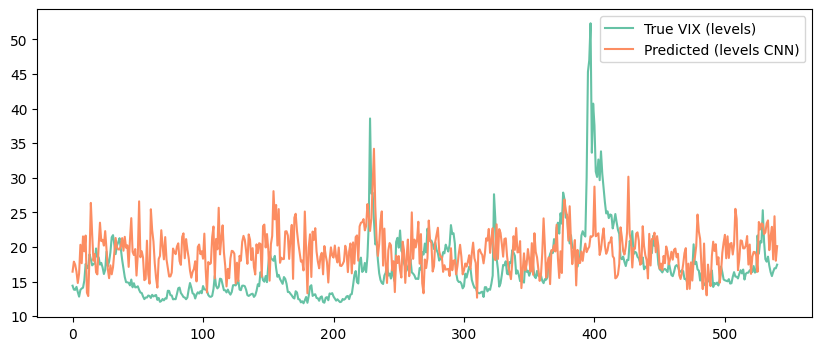

In [23]:
tf.keras.backend.clear_session()
tf.random.set_seed(1234)

model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(15, 15, 5)),

    # filters_0 = 8
    tf.keras.layers.Conv2D(8, 3, padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(2),

    # filters_1 = 56
    tf.keras.layers.Conv2D(56, 3, padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(2),

    # filters_2 = 56
    tf.keras.layers.Conv2D(56, 3, padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(1024),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dropout(0.5, seed=1234),

    tf.keras.layers.Dense(1)
])

model.compile(loss="mse",optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4))
checkpoint = tf.keras.callbacks.ModelCheckpoint("model.h5",monitor="val_loss",save_best_only=True,mode="min")

val_size = int(0.2 * len(X_train))

X_tr, X_val = X_train_l[:-val_size], X_train_l[-val_size:]
y_tr, y_val = y_train_l[:-val_size], y_train_l[-val_size:]

history = model.fit(X_tr,y_tr,validation_data=(X_val, y_val),epochs=50,callbacks=[checkpoint],shuffle=False,verbose=0)

# Predict (scaled)
y_pred_train_scaled = model.predict(X_train_l).flatten()
y_pred_test_scaled  = model.predict(X_test_l).flatten()

# Rescale back to real VIX values
y_pred_train_rescaled = scaler_y.inverse_transform(y_pred_train_scaled.reshape(-1,1)).flatten()
y_pred_test_rescaled  = scaler_y.inverse_transform(y_pred_test_scaled.reshape(-1,1)).flatten()

y_pred_naive = y_test_l[:-1]  # predict tomorrow = today
evaluate(y_test_actual_l[1:], y_pred_naive, "Naive model as the baseline levels model")
evaluate(y_train_actual_l, y_pred_train_rescaled, "train levels model")
evaluate(y_test_actual_l, y_pred_test_rescaled, "test levels model")


# Optionally, plot predictions vs true
plt.figure(figsize=(10,4))
plt.plot(y_test_actual_l, label="True VIX (levels)")
plt.plot(y_pred_test_rescaled, label="Predicted (levels CNN)")
plt.legend()
plt.show()

In [31]:
y_pred_naive = y_train_l[:-1]  # predict tomorrow = today

evaluate(y_train_actual_l[1:], y_pred_naive, "Naive model as the baseline levels model")


Naive model as the baseline levels model — MSE: 391.163153, MAE: 18.630264


##### **Step 3-2**

Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4193.8589 - val_loss: 17.4203
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 13.4648 - val_loss: 8.2412
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.7247 - val_loss: 6.5397
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.9881 - val_loss: 4.6862
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.2620 - val_loss: 3.9453
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.4562 - val_loss: 3.4807
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.8586 - val_loss: 3.1223
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2.5772 - val_loss: 3.2869
Epoch 9/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 2.3108 - val_loss: 3.0778
Epoch 10/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 2.0467 - val_loss: 2.7901
Epoch 11/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.8518 - val_loss: 2.6553
Epoch 12/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.

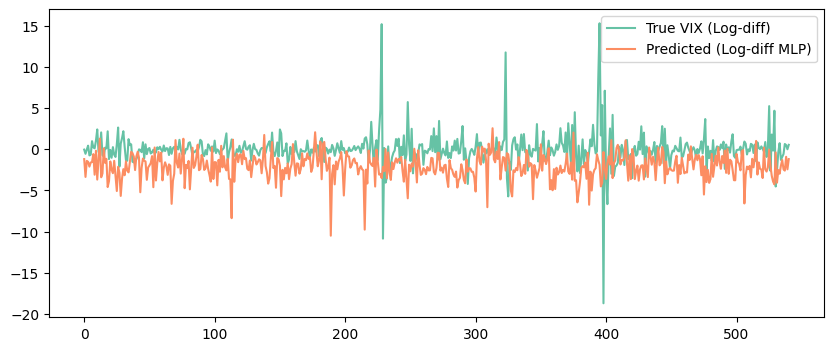

In [24]:
from tensorflow.keras.layers import Dense, Flatten

X_logdiff = df_logdiff.drop("y", axis=1).values
y_logdiff = df_logdiff["y"].values
window_size = 15
n_features = X_logdiff.shape[1]
X_train_logdiff = X_train_array(X_logdiff, 15)
X_gaf_logdiff = gaf_func(X_train_logdiff, X_logdiff.shape[1], window_size)
y_logdiff = y_logdiff[window_size:]

#plot_lags(n_features, X_gaf_logdiff)

def build_train_gfa_mlp(X_train, y_train, X_test, y_test, scaler_y, epochs=50, hidden_units=[256, 256, 64]):
    model = Sequential()
    model.add(Flatten(input_shape=X_train.shape[1:]))  # flatten GAF image

    # Add hidden layers
    for units in hidden_units:
        model.add(Dense(units, activation='relu'))

    model.add(Dense(1))  # output layer

    model.compile(optimizer='adam', loss='mse')

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        verbose=1
    )

    # Predictions
    y_pred_train = model.predict(X_train).flatten()
    y_pred_test = model.predict(X_test).flatten()

    # Inverse scale
    y_pred_train_rescaled = scaler_y.inverse_transform(y_pred_train.reshape(-1,1)).flatten()
    y_pred_test_rescaled = scaler_y.inverse_transform(y_pred_test.reshape(-1,1)).flatten()

    return model, history, y_pred_train_rescaled, y_pred_test_rescaled


y_train_actual_logdiff, y_test_actual_logdiff, X_train_logdiff, X_test_logdiff, y_train_logdiff, y_test_logdiff = split_data(X_gaf_logdiff, y_logdiff, scaler_y)

mlp_logdiff, hist_logdiff, ypred_logdiff_tr, ypred_logdiff_te = build_train_gfa_mlp(X_train_logdiff, y_train_logdiff, X_test_logdiff, y_test_logdiff, scaler_y)

print("Performance on test set:")
evaluate(y_train_actual_logdiff, ypred_logdiff_tr, "Log-diff model_train")
evaluate(y_test_actual_logdiff, ypred_logdiff_te, "Log-diff model_test")

#  plot predictions vs true
plt.figure(figsize=(10,4))
plt.plot(y_test_actual_logdiff, label="True VIX (Log-diff)")
plt.plot(ypred_logdiff_te, label="Predicted (Log-diff MLP)")
plt.legend()
plt.show()

##### **Step 3-3**

In [25]:
X_fd = df_fd.drop("y", axis=1).values
y_fd = df_fd["y"].values
window_size = 25
n_features = X_fd.shape[1]
X_train_fd = X_train_array(X_fd, 25)
X_gaf_fd = gaf_func(X_train_fd, X_fd.shape[1], window_size)
y_fd = y_fd[window_size:]

#plot_lags(n_features, X_gaf_fd)


y_train_actual_fd, y_test_actual_fd, X_train_fd, X_test_fd, y_train_fd, y_test_fd = split_data(X_gaf_fd, y_fd, scaler_y)
"""
# Clear session before hyperparameter tuning
K.clear_session()

# Initialize tuner
hypermodel = CNN_model()
stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)
tuner = kt.Hyperband(hypermodel,objective=kt.Objective("val_loss", direction="min"),max_epochs=10,factor=3,seed=1234,overwrite=True)

val_split = 0.2
# Search for best hyperparameters
tuner.search(X_train_fd, y_train_fd, validation_split=val_split,  callbacks=[stop])
best_hps_fd = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters:", best_hps_fd.values)

Trial 30 Complete [00h 00m 23s]
val_loss: 0.48407140374183655

Best val_loss So Far: 0.48407140374183655
Total elapsed time: 00h 09m 18s
Best hyperparameters: {'n_dropout': 0.5, 'num_layers': 3, 'filters_0': 8,
                       'filters_1': 56, 'learning_rate': 0.0001, 'filters_2': 56, 'tuner/epochs': 10,
                       'tuner/initial_epoch': 0, 'tuner/bracket': 0, 'tuner/round': 0}"""

'\n# Clear session before hyperparameter tuning\nK.clear_session()\n\n# Initialize tuner\nhypermodel = CNN_model()\nstop = tf.keras.callbacks.EarlyStopping(monitor=\'val_loss\',patience=5,restore_best_weights=True)\ntuner = kt.Hyperband(hypermodel,objective=kt.Objective("val_loss", direction="min"),max_epochs=10,factor=3,seed=1234,overwrite=True)\n\nval_split = 0.2\n# Search for best hyperparameters\ntuner.search(X_train_fd, y_train_fd, validation_split=val_split,  callbacks=[stop])\nbest_hps_fd = tuner.get_best_hyperparameters(num_trials=1)[0]\n\nprint("Best hyperparameters:", best_hps_fd.values)\n\nTrial 30 Complete [00h 00m 23s]\nval_loss: 0.48407140374183655\n\nBest val_loss So Far: 0.48407140374183655\nTotal elapsed time: 00h 09m 18s\nBest hyperparameters: {\'n_dropout\': 0.5, \'num_layers\': 3, \'filters_0\': 8, \n                       \'filters_1\': 56, \'learning_rate\': 0.0001, \'filters_2\': 56, \'tuner/epochs\': 10, \n                       \'tuner/initial_epoch\': 0, \'tun

In [26]:
tf.keras.backend.clear_session()
tf.random.set_seed(1234)

model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(25, 25, 5)),

    # filters_0 = 8
    tf.keras.layers.Conv2D(8, 3, padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(2),

    # filters_1 = 56
    tf.keras.layers.Conv2D(56, 3, padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(2),

    # filters_2 = 56
    tf.keras.layers.Conv2D(56, 3, padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(2),


    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(1024),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dropout(0.2, seed=1234),

    tf.keras.layers.Dense(1)
])

model.compile(loss="mse",optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001))
checkpoint = tf.keras.callbacks.ModelCheckpoint("model.h5",monitor="val_loss",save_best_only=True,mode="min")

val_size = int(0.2 * len(X_train))

X_tr_fd, X_val_fd = X_train_fd[:-val_size], X_train_fd[-val_size:]
y_tr_fd, y_val_fd = y_train_fd[:-val_size], y_train_fd[-val_size:]

history = model.fit(X_tr_fd,y_tr_fd,validation_data=(X_val_fd, y_val_fd),epochs=200,callbacks=[checkpoint],shuffle=False,verbose=0)

# Predict (scaled)
y_pred_train_scaled_fd = model.predict(X_train_fd).flatten()
y_pred_test_scaled_fd  = model.predict(X_test_fd).flatten()

# Rescale back to real VIX values
y_pred_train_rescaled_fd = scaler_y.inverse_transform(y_pred_train_scaled_fd.reshape(-1,1)).flatten()
y_pred_test_rescaled_fd  = scaler_y.inverse_transform(y_pred_test_scaled_fd.reshape(-1,1)).flatten()

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


Naive model -fractional differencing time series — MSE: 71.282174, MAE: 7.830381
train fractional differencing time series — MSE: 15.616180, MAE: 2.683462
test levels fractional differencing time series — MSE: 19.075004, MAE: 3.069464


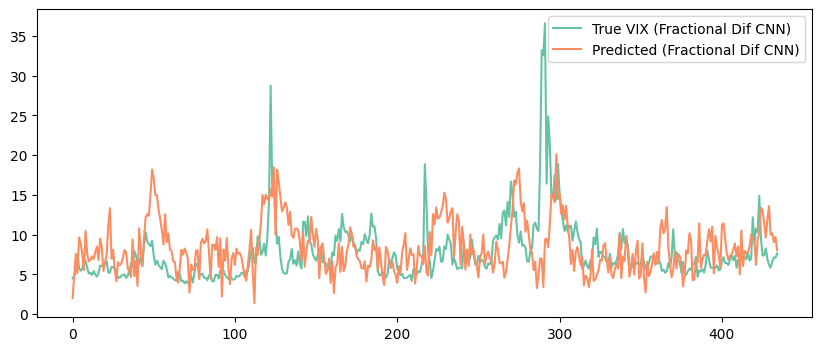

In [28]:
y_pred_naive_fd = y_test_fd[:-1]  # predict tomorrow = today
evaluate(y_test_actual_fd[1:], y_pred_naive_fd, "Naive model -fractional differencing time series")
evaluate(y_train_actual_fd, y_pred_train_rescaled_fd, "train fractional differencing time series")
evaluate(y_test_actual_fd, y_pred_test_rescaled_fd, "test levels fractional differencing time series")


# Optionally, plot predictions vs true
plt.figure(figsize=(10,4))
plt.plot(y_test_actual_fd, label="True VIX (Fractional Dif CNN)")
plt.plot(y_pred_test_rescaled_fd, label="Predicted (Fractional Dif CNN)")
plt.legend()
plt.show()